# Phase 3.5: Fine-Tuning TrOCR-Small for Hindi HTR

**Goal:** Fine-tune `microsoft/trocr-small-handwritten` on our 200k Hindi dataset.

**Target:** >96% char accuracy, >90% word accuracy (vs Phase 3 CRNN: 93%/84%)

**Platform:** Kaggle T4 GPU | ~6-8 hours

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
    "transformers>=4.38", "datasets", "evaluate", "jiwer",
    "editdistance", "accelerate", "sentencepiece"])
print("All packages installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 2.6 MB/s eta 0:00:00
All packages installed.


## 1. Imports & Configuration

In [2]:
import json, os, time, random, unicodedata, warnings, urllib.request
from pathlib import Path
from io import BytesIO
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image, ImageOps

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import editdistance

from transformers import (
    VisionEncoderDecoderModel,
    TrOCRProcessor,
    get_scheduler,
)

warnings.filterwarnings("ignore")
random.seed(42); np.random.seed(42); torch.manual_seed(42)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Paths
DATASET_DIR = Path("/kaggle/input/datasets/nehamalik10/hindi-ocr-new-dataset")
PHASE2_DIR  = Path("/kaggle/input/datasets/nehamalik10/hindi-htr-phase2-artifacts-improved")
OUTPUT_DIR  = Path("/kaggle/working/phase3_5")
CKPT_DIR    = OUTPUT_DIR / "checkpoints"
RESULTS_DIR = OUTPUT_DIR / "results"
for d in [OUTPUT_DIR, CKPT_DIR, RESULTS_DIR]: d.mkdir(parents=True, exist_ok=True)

# Hyperparameters
MODEL_NAME       = "microsoft/trocr-small-handwritten"
MAX_TARGET_LEN   = 32
BATCH_SIZE       = 16
EPOCHS_PHASE_A   = 3
EPOCHS_PHASE_B   = 12
LR_ENCODER       = 1e-5
LR_DECODER       = 5e-5
WEIGHT_DECAY     = 0.01
WARMUP_STEPS     = 500
GRAD_CLIP        = 1.0
EVAL_SAMPLES     = 2000
NUM_BEAMS_EVAL   = 4
NUM_BEAMS_TEST   = 8
NUM_WORKERS      = 2

print("Configuration ready.")


Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
Configuration ready.


## 2. Devanagari Font Setup

In [3]:
FONT_DIR = Path("/kaggle/working/fonts"); FONT_DIR.mkdir(exist_ok=True)
FONT_PATH = FONT_DIR / "NotoSansDevanagari.ttf"
FONT_URL = "https://github.com/google/fonts/raw/main/ofl/notosansdevanagari/NotoSansDevanagari%5Bwdth%2Cwght%5D.ttf"
if not FONT_PATH.exists():
    for c in [Path("/usr/share/fonts/truetype/noto/NotoSansDevanagari-Regular.ttf")]:
        if c.exists(): FONT_PATH.write_bytes(c.read_bytes()); break
    else:
        print("Downloading font..."); urllib.request.urlretrieve(FONT_URL, FONT_PATH)
fm.fontManager.addfont(str(FONT_PATH))
DEVA_FONT = fm.FontProperties(fname=str(FONT_PATH))
mpl.rcParams["axes.unicode_minus"] = False
print("Font ready.")


Font ready.


## 3. Load Phase 2 Artifacts

In [4]:
with open(PHASE2_DIR / "char_vocab.json", "r", encoding="utf-8") as f:
    vocab_data = json.load(f)
phase2_c2i = vocab_data["char_to_idx"]
phase2_i2c = {int(k): v for k, v in vocab_data["idx_to_char"].items()}
with open(PHASE2_DIR / "preprocess_config.json", "r") as f:
    preprocess_config = json.load(f)

CTC_SPECIAL = {"<BLANK>", "<UNK>", "<PAD>"}
actual_chars = sorted([ch for ch in phase2_c2i if ch not in CTC_SPECIAL],
                      key=lambda c: phase2_c2i[c])
print(f"Phase 2 vocab: {len(phase2_c2i)} entries, {len(actual_chars)} actual characters")
print(f"Sample: {actual_chars[:8]} ... {actual_chars[-3:]}")


Phase 2 vocab: 139 entries, 136 actual characters
Sample: [' ', '!', '"', '#', '%', "'", '(', ')'] ... ['\u200d', '“', '”']


## 4. Custom Devanagari Tokenizer

Character-level tokenizer mapping each Devanagari character to a unique token ID.

Special tokens: `<pad>=0, <bos>=1, <eos>=2, <unk>=3`

In [5]:
PAD_ID, BOS_ID, EOS_ID, UNK_ID = 0, 1, 2, 3

char_to_token = {}
token_to_char = {}
for i, ch in enumerate(actual_chars):
    tid = i + 4
    char_to_token[ch] = tid
    token_to_char[tid] = ch
VOCAB_SIZE = 4 + len(actual_chars)

def encode_text(text):
    text = unicodedata.normalize("NFC", text)
    ids = [char_to_token.get(ch, UNK_ID) for ch in text]
    ids.append(EOS_ID)
    return ids

def decode_tokens(token_ids):
    chars = []
    for tid in token_ids:
        if isinstance(tid, torch.Tensor): tid = tid.item()
        if tid == EOS_ID or tid == PAD_ID: break
        if tid == BOS_ID: continue
        if tid in token_to_char: chars.append(token_to_char[tid])
    return "".join(chars)

# Roundtrip test
test_texts = ["\u0939\u093f\u0928\u094d\u0926\u0940", "\u092d\u093e\u0930\u0924", "\u0915\u0947 \u0932\u093f\u090f"]
print(f"Vocab size: {VOCAB_SIZE}")
for t in test_texts:
    d = decode_tokens(encode_text(t))
    print(f"  '{t}' roundtrip: {'PASS' if d == t else 'FAIL: ' + d}")
print("Tokenizer ready.")


Vocab size: 140
  'हिन्दी' roundtrip: PASS
  'भारत' roundtrip: PASS
  'के लिए' roundtrip: PASS
Tokenizer ready.


## 5. Load Dataset

In [6]:
train_df = pd.read_parquet(DATASET_DIR / "train.parquet")
val_df   = pd.read_parquet(DATASET_DIR / "val.parquet")
test_df  = pd.read_parquet(DATASET_DIR / "test.parquet")
for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"  {name:5s}: {len(df):>7,}")
print(f"Columns: {train_df.columns.tolist()}")


  Train: 150,000
  Val  :  20,000
  Test :  30,000
Columns: ['image_name', 'image', 'text']


## 6. Image Preprocessing & Augmentation

**Pipeline:** Raw image -> grayscale -> autocontrast -> tight crop -> RGB -> augmentation -> TrOCR processor

In [7]:
IMG_COL, LABEL_COL = "image", "text"
TIGHT_CROP_PAD = 2

def row_to_image(row):
    value = row[IMG_COL]
    if isinstance(value, Image.Image): return value.convert("RGB")
    if isinstance(value, dict):
        if value.get("bytes") is not None:
            return Image.open(BytesIO(value["bytes"])).convert("RGB")
        if value.get("path") is not None:
            return Image.open(value["path"]).convert("RGB")
    if isinstance(value, (bytes, bytearray)):
        return Image.open(BytesIO(value)).convert("RGB")
    if isinstance(value, np.ndarray):
        return Image.fromarray(value).convert("RGB")
    raise TypeError(f"Unsupported image type: {type(value)}")

def preprocess_for_trocr(pil_img):
    gray = np.array(pil_img.convert("L"))
    p2, p98 = np.percentile(gray, (2, 98))
    if p98 > p2:
        gray = np.clip((gray - p2) / (p98 - p2) * 255, 0, 255).astype(np.uint8)
    _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    coords = cv2.findNonZero(bw)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        pad = TIGHT_CROP_PAD
        y1, y2 = max(0, y-pad), min(gray.shape[0], y+h+pad)
        x1, x2 = max(0, x-pad), min(gray.shape[1], x+w+pad)
        gray = gray[y1:y2, x1:x2]
    # Ensure minimum size
    if gray.shape[0] < 4 or gray.shape[1] < 4:
        gray = np.full((32, 128), 255, dtype=np.uint8)
    return Image.fromarray(cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB))

def aug_rotate(img):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), random.uniform(-5, 5), 1.0)
    return cv2.warpAffine(img, M, (w, h), borderValue=(255,255,255))
def aug_noise(img):
    n = np.random.normal(0, random.uniform(5, 15), img.shape).astype(np.float32)
    return np.clip(img.astype(np.float32) + n, 0, 255).astype(np.uint8)
def aug_erode_dilate(img):
    k = np.ones((random.choice([2,3]),)*2, np.uint8)
    return cv2.erode(img, k, iterations=1) if random.random()<0.5 else cv2.dilate(img, k, iterations=1)
def aug_shear(img):
    h, w = img.shape[:2]
    M = np.float32([[1, random.uniform(-0.2, 0.2), 0], [0, 1, 0]])
    return cv2.warpAffine(img, M, (w, h), borderValue=(255,255,255))
def aug_brightness(img):
    return np.clip(img.astype(np.float32)*random.uniform(0.7,1.3)+random.uniform(-20,20), 0, 255).astype(np.uint8)
def aug_cutout(img):
    h, w = img.shape[:2]
    ch, cw = random.randint(h//8,h//4), random.randint(w//8,w//4)
    y, x = random.randint(0,h-ch), random.randint(0,w-cw)
    c = img.copy(); c[y:y+ch, x:x+cw] = 255; return c

def augment_image(pil_img):
    img = np.array(pil_img)
    if random.random() < 0.5:  img = aug_rotate(img)
    if random.random() < 0.4:  img = aug_noise(img)
    if random.random() < 0.2:  img = aug_erode_dilate(img)
    if random.random() < 0.4:  img = aug_shear(img)
    if random.random() < 0.35: img = aug_brightness(img)
    if random.random() < 0.25: img = aug_cutout(img)
    return Image.fromarray(img)

print("Preprocessing & augmentation ready.")


Preprocessing & augmentation ready.


## 7. TrOCR Dataset & DataLoaders

In [8]:
# Load TrOCR processor (for image preprocessing only)
processor = TrOCRProcessor.from_pretrained(MODEL_NAME)

class TrOCRHindiDataset(Dataset):
    def __init__(self, df, processor, augment=False):
        self.df = df.reset_index(drop=True)
        self.processor = processor
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = unicodedata.normalize("NFC", str(row[LABEL_COL]))

        # Load and preprocess image
        try:
            pil_img = row_to_image(row)
            pil_img = preprocess_for_trocr(pil_img)
        except Exception:
            pil_img = Image.new("RGB", (128, 32), color=255)
            text = ""

        # Augmentation (training only)
        if self.augment:
            pil_img = augment_image(pil_img)

        # Apply TrOCR processor (resize + normalize)
        pixel_values = self.processor(images=pil_img, return_tensors="pt").pixel_values.squeeze(0)

        # Encode label
        label_ids = encode_text(text)
        if len(label_ids) > MAX_TARGET_LEN:
            label_ids = label_ids[:MAX_TARGET_LEN - 1] + [EOS_ID]

        # Pad with -100 (ignored in loss)
        padded = label_ids + [-100] * (MAX_TARGET_LEN - len(label_ids))
        labels = torch.tensor(padded, dtype=torch.long)

        return {"pixel_values": pixel_values, "labels": labels}

def collate_fn(batch):
    pixel_values = torch.stack([x["pixel_values"] for x in batch])
    labels = torch.stack([x["labels"] for x in batch])
    return {"pixel_values": pixel_values, "labels": labels}

# Create datasets
train_dataset = TrOCRHindiDataset(train_df, processor, augment=True)
val_dataset   = TrOCRHindiDataset(val_df, processor, augment=False)
test_dataset  = TrOCRHindiDataset(test_df, processor, augment=False)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE*2, shuffle=False,
                          collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE*2, shuffle=False,
                          collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True)

# Quick check
batch = next(iter(train_loader))
print(f"pixel_values: {batch['pixel_values'].shape}")
print(f"labels: {batch['labels'].shape}")
print(f"Train batches/epoch: {len(train_loader)}")
print(f"Datasets ready.")


preprocessor_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

The image processor of type `DeiTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/327 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

pixel_values: torch.Size([16, 3, 384, 384])
labels: torch.Size([16, 32])
Train batches/epoch: 9375
Datasets ready.


## 8. Sanity Check: Visualize Batch

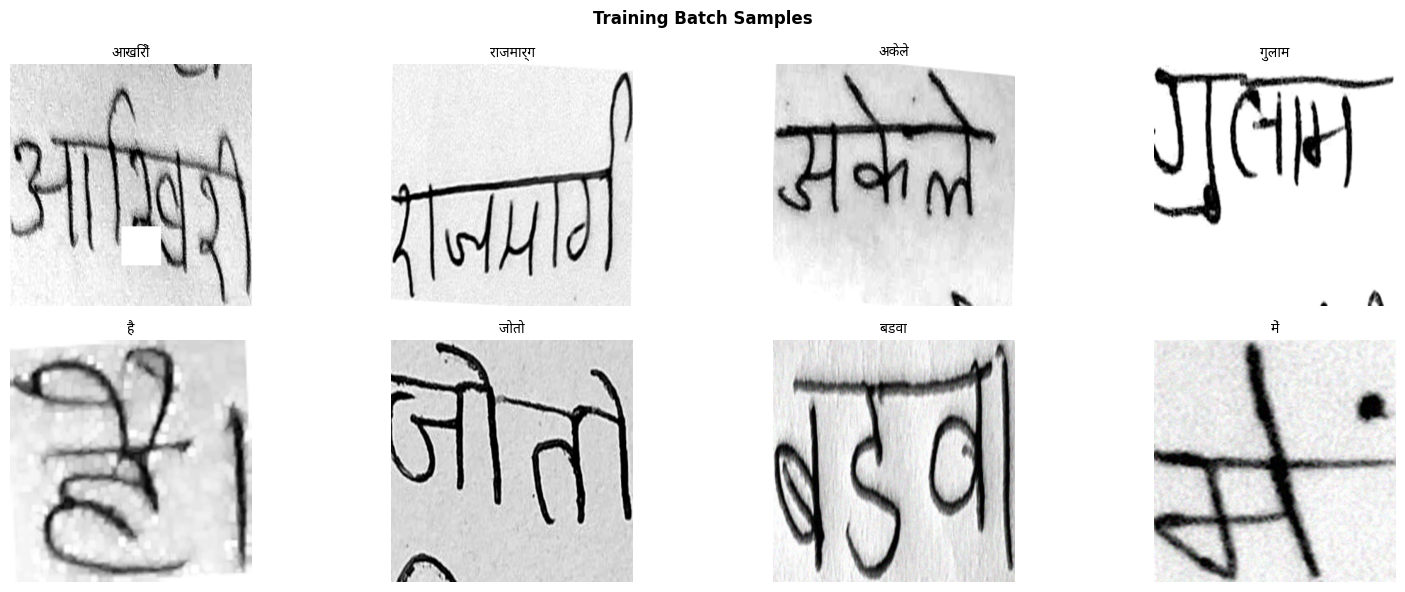

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
batch = next(iter(train_loader))
for i, ax in enumerate(axes.flat):
    if i >= batch["pixel_values"].shape[0]: break
    img = batch["pixel_values"][i].permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    label_ids = batch["labels"][i]
    label_ids = label_ids[label_ids != -100].tolist()
    text = decode_tokens(label_ids)
    ax.imshow(img)
    ax.set_title(text, fontsize=10, fontproperties=DEVA_FONT)
    ax.axis("off")
plt.suptitle("Training Batch Samples", fontweight="bold")
plt.tight_layout(); plt.show()


## 9. Load & Configure TrOCR Model

In [10]:
# Load pretrained model
model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)

# Resize decoder for our Devanagari vocab
model.decoder.resize_token_embeddings(VOCAB_SIZE)

# Configure model IDs (required for forward pass / loss computation)
model.config.decoder_start_token_id = BOS_ID
model.config.pad_token_id = PAD_ID
model.config.eos_token_id = EOS_ID
model.config.vocab_size = VOCAB_SIZE

# Also set decoder config
model.decoder.config.decoder_start_token_id = BOS_ID
model.decoder.config.pad_token_id = PAD_ID
model.decoder.config.eos_token_id = EOS_ID
model.decoder.config.vocab_size = VOCAB_SIZE

# Configure generation parameters (must use generation_config, NOT model.config)
model.generation_config.max_length = MAX_TARGET_LEN
model.generation_config.early_stopping = True
model.generation_config.no_repeat_ngram_size = 0
model.generation_config.length_penalty = 1.0
model.generation_config.num_beams = NUM_BEAMS_EVAL
model.generation_config.decoder_start_token_id = BOS_ID
model.generation_config.pad_token_id = PAD_ID
model.generation_config.eos_token_id = EOS_ID
model.generation_config.bos_token_id = BOS_ID

model = model.to(device)

# Count parameters
enc_params = sum(p.numel() for p in model.encoder.parameters())
dec_params = sum(p.numel() for p in model.decoder.parameters())
total = enc_params + dec_params
print(f"Encoder: {enc_params:,} params")
print(f"Decoder: {dec_params:,} params")
print(f"Total:   {total:,} params")
print(f"\n{'='*60}")
print(f"  MODEL & TRAINING CONFIGURATION")
print(f"{'='*60}")
print(f"  Model          : {MODEL_NAME}")
print(f"  Architecture   : ViT-DeiT (encoder) + GPT-2 (decoder)")
print(f"  Vocab size     : {VOCAB_SIZE}")
print(f"  Max target len : {MAX_TARGET_LEN}")
print(f"  Batch size     : {BATCH_SIZE}")
print(f"  Image size     : 384 x 384 (RGB)")
print(f"  Phase A        : {EPOCHS_PHASE_A} epochs (decoder only, LR={LR_DECODER})")
print(f"  Phase B        : {EPOCHS_PHASE_B} epochs (full, enc LR={LR_ENCODER}, dec LR={LR_DECODER})")
print(f"  Total epochs   : {EPOCHS_PHASE_A + EPOCHS_PHASE_B}")
print(f"  Warmup steps   : {WARMUP_STEPS}")
print(f"  Grad clip      : {GRAD_CLIP}")
print(f"  Encoder params : {enc_params:,}")
print(f"  Decoder params : {dec_params:,}")
print(f"  Total params   : {total:,}")
print(f"  Train samples  : {len(train_df):,}")
print(f"  Val samples    : {len(val_df):,}")
print(f"  Test samples   : {len(test_df):,}")
print(f"  Batches/epoch  : {len(train_loader):,}")
print(f"{'='*60}")
print(f"Model loaded and configured.")


pytorch_model.bin:   0%|          | 0.00/246M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/360 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-small-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoder: 21,960,192 params
Decoder: 6,917,632 params
Total:   28,877,824 params

  MODEL & TRAINING CONFIGURATION
  Model          : microsoft/trocr-small-handwritten
  Architecture   : ViT-DeiT (encoder) + GPT-2 (decoder)
  Vocab size     : 140
  Max target len : 32
  Batch size     : 16
  Image size     : 384 x 384 (RGB)
  Phase A        : 3 epochs (decoder only, LR=5e-05)
  Phase B        : 12 epochs (full, enc LR=1e-05, dec LR=5e-05)
  Total epochs   : 15
  Warmup steps   : 500
  Grad clip      : 1.0
  Encoder params : 21,960,192
  Decoder params : 6,917,632
  Total params   : 28,877,824
  Train samples  : 150,000
  Val samples    : 20,000
  Test samples   : 30,000
  Batches/epoch  : 9,375
Model loaded and configured.


## 10. CER / WER Evaluation

In [11]:
@torch.no_grad()
def evaluate_model(model, loader, max_samples=None, num_beams=4):
    model.eval()
    total_cer, total_wer, count = 0.0, 0.0, 0

    for batch in loader:
        if max_samples and count >= max_samples: break
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"]

        # Generate predictions
        generated = model.generate(
            pixel_values,
            max_length=MAX_TARGET_LEN,
            num_beams=num_beams,
            decoder_start_token_id=BOS_ID,
            early_stopping=True,
        )

        for i in range(pixel_values.size(0)):
            if max_samples and count >= max_samples: break
            pred_text = decode_tokens(generated[i])
            gt_ids = labels[i][labels[i] != -100].tolist()
            gt_text = decode_tokens(gt_ids)

            if len(gt_text) == 0:
                count += 1
                continue

            ed = editdistance.eval(pred_text, gt_text)
            total_cer += ed / max(len(gt_text), 1)
            total_wer += (0.0 if pred_text == gt_text else 1.0)
            count += 1

    avg_cer = total_cer / max(count, 1)
    avg_wer = total_wer / max(count, 1)
    return avg_cer, avg_wer, count

print("Evaluation function ready.")


Evaluation function ready.


## 11. Training Setup

**Phase A (3 epochs):** Freeze encoder, train decoder only (LR=5e-5)

**Phase B (20 epochs):** Unfreeze all, differential LR (encoder=1e-5, decoder=5e-5)

In [12]:
def freeze_encoder(model):
    for p in model.encoder.parameters():
        p.requires_grad = False
    print("Encoder FROZEN")

def unfreeze_encoder(model):
    for p in model.encoder.parameters():
        p.requires_grad = True
    print("Encoder UNFROZEN")

def create_optimizer(model, phase="A"):
    if phase == "A":
        # Only decoder params
        params = [p for p in model.decoder.parameters() if p.requires_grad]
        return optim.AdamW(params, lr=LR_DECODER, weight_decay=WEIGHT_DECAY)
    else:
        # Differential LR
        encoder_params = [p for p in model.encoder.parameters() if p.requires_grad]
        decoder_params = [p for p in model.decoder.parameters() if p.requires_grad]
        return optim.AdamW([
            {"params": encoder_params, "lr": LR_ENCODER},
            {"params": decoder_params, "lr": LR_DECODER},
        ], weight_decay=WEIGHT_DECAY)

scaler = torch.amp.GradScaler("cuda")
best_cer = float("inf")
history = {"loss": [], "val_cer": [], "val_wer": [], "lr": [], "epoch": [], "phase": []}

print("Training setup ready.")


Training setup ready.


## 12. Training Loop

In [13]:
def train_one_epoch(model, loader, optimizer, scheduler, epoch_num, total_epochs):
    model.train()
    epoch_loss, n_batches = 0.0, 0
    t0 = time.time()

    for bi, batch in enumerate(loader):
        optimizer.zero_grad()
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        with torch.amp.autocast("cuda"):
            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        if scheduler: scheduler.step()

        epoch_loss += loss.item()
        n_batches += 1

        if (bi + 1) % 200 == 0:
            print(f"  [{bi+1}/{len(loader)}] loss={loss.item():.4f}")

    avg_loss = epoch_loss / max(n_batches, 1)
    elapsed = time.time() - t0
    return avg_loss, elapsed

def run_training(model, phase, n_epochs, start_epoch=1):
    global best_cer

    if phase == "A":
        freeze_encoder(model)
    else:
        unfreeze_encoder(model)

    optimizer = create_optimizer(model, phase)
    total_steps = n_epochs * len(train_loader)
    scheduler = get_scheduler("cosine", optimizer=optimizer,
                              num_warmup_steps=min(WARMUP_STEPS, total_steps//5),
                              num_training_steps=total_steps)

    print(f"\n{'='*60}")
    print(f"PHASE {phase}: {n_epochs} epochs | LR={optimizer.param_groups[0]['lr']:.1e}")
    print(f"{'='*60}")

    for ep in range(1, n_epochs + 1):
        global_ep = start_epoch + ep - 1
        print(f"\nEpoch {global_ep} (Phase {phase} - {ep}/{n_epochs})")
        print("-" * 40)

        avg_loss, elapsed = train_one_epoch(model, train_loader, optimizer, scheduler,
                                            global_ep, start_epoch + n_epochs - 1)
        val_cer, val_wer, _ = evaluate_model(model, val_loader, max_samples=EVAL_SAMPLES)
        lr = optimizer.param_groups[0]["lr"]

        history["loss"].append(avg_loss)
        history["val_cer"].append(val_cer)
        history["val_wer"].append(val_wer)
        history["lr"].append(lr)
        history["epoch"].append(global_ep)
        history["phase"].append(phase)

        print(f"  loss={avg_loss:.4f} | CER={val_cer:.4f} | WER={val_wer:.4f} | "
              f"LR={lr:.2e} | time={elapsed:.0f}s")

        if val_cer < best_cer:
            best_cer = val_cer
            torch.save({
                "epoch": global_ep,
                "phase": phase,
                "model_state_dict": model.state_dict(),
                "val_cer": val_cer,
                "val_wer": val_wer,
                "vocab_size": VOCAB_SIZE,
                "char_to_token": char_to_token,
                "token_to_char": {str(k): v for k, v in token_to_char.items()},
            }, CKPT_DIR / "best_model.pt")
            print(f"  >> Best model saved! (CER={val_cer:.4f})")

    return start_epoch + n_epochs

# ── Phase A: Decoder only ──
next_epoch = run_training(model, "A", EPOCHS_PHASE_A, start_epoch=1)

# ── Phase B: Full fine-tuning ──
next_epoch = run_training(model, "B", EPOCHS_PHASE_B, start_epoch=next_epoch)

print(f"\n{'='*60}")
print(f"Training complete! Best CER: {best_cer:.4f}")
print(f"{'='*60}")


Encoder FROZEN

PHASE A: 3 epochs | LR=0.0e+00

Epoch 1 (Phase A - 1/3)
----------------------------------------


model.safetensors:   0%|          | 0.00/246M [00:00<?, ?B/s]

  [200/9375] loss=3.2601
  [400/9375] loss=2.8763
  [600/9375] loss=2.3553
  [800/9375] loss=2.1914
  [1000/9375] loss=1.9729
  [1200/9375] loss=2.2340
  [1400/9375] loss=1.9652
  [1600/9375] loss=1.9767
  [1800/9375] loss=1.9415
  [2000/9375] loss=1.5521
  [2200/9375] loss=1.7745
  [2400/9375] loss=1.6710
  [2600/9375] loss=1.6971
  [2800/9375] loss=1.6824
  [3000/9375] loss=1.7386
  [3200/9375] loss=1.8631
  [3400/9375] loss=1.4893
  [3600/9375] loss=1.3145
  [3800/9375] loss=1.2284
  [4000/9375] loss=1.3875
  [4200/9375] loss=1.3614
  [4400/9375] loss=1.3720
  [4600/9375] loss=1.4731
  [4800/9375] loss=1.0350
  [5000/9375] loss=1.8404
  [5200/9375] loss=1.4977
  [5400/9375] loss=1.5097
  [5600/9375] loss=1.5676
  [5800/9375] loss=1.1842
  [6000/9375] loss=0.8233
  [6200/9375] loss=1.1330
  [6400/9375] loss=1.0809
  [6600/9375] loss=1.4759
  [6800/9375] loss=1.3042
  [7000/9375] loss=1.0531
  [7200/9375] loss=1.4905
  [7400/9375] loss=1.0205
  [7600/9375] loss=1.2751
  [7800/9375] lo

## 13. Training Curves

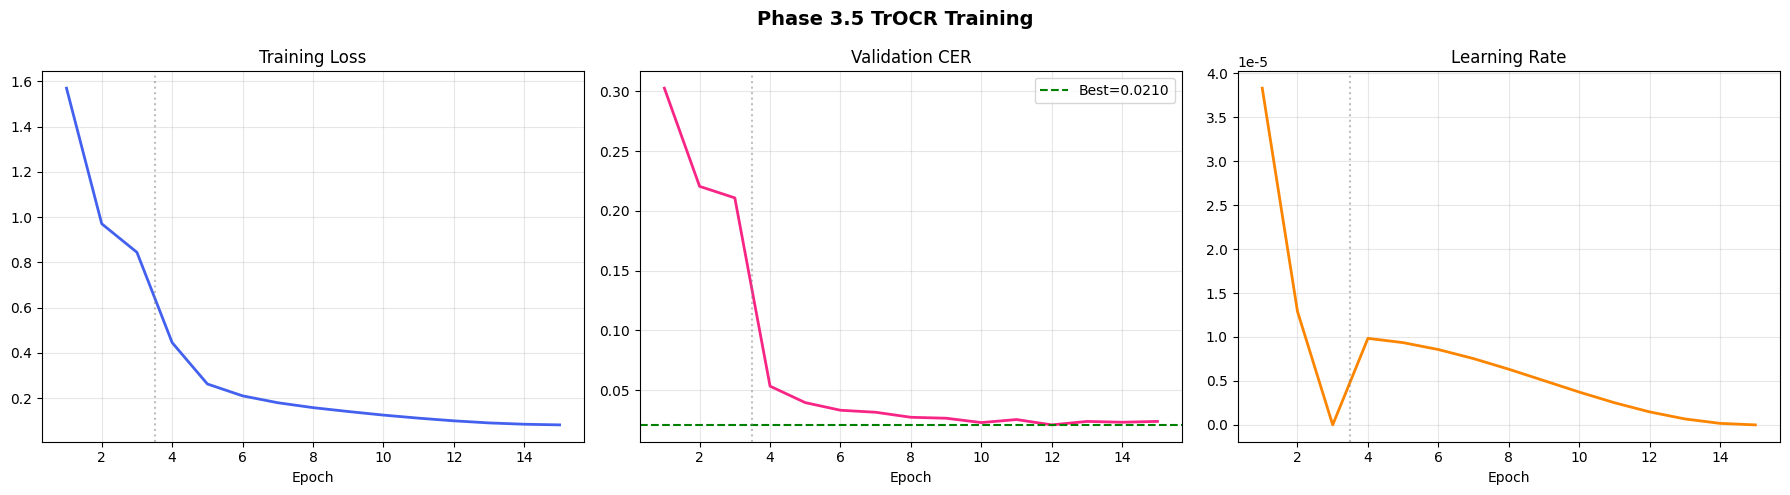

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history["epoch"], history["loss"], color="#4361ee", lw=2)
axes[0].set_title("Training Loss"); axes[0].set_xlabel("Epoch"); axes[0].grid(alpha=0.3)

axes[1].plot(history["epoch"], history["val_cer"], color="#f72585", lw=2)
axes[1].axhline(best_cer, color="green", ls="--", label=f"Best={best_cer:.4f}")
axes[1].set_title("Validation CER"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(history["epoch"], history["lr"], color="#fb8500", lw=2)
axes[2].set_title("Learning Rate"); axes[2].set_xlabel("Epoch"); axes[2].grid(alpha=0.3)

# Mark phase boundary
boundary = EPOCHS_PHASE_A + 0.5
for ax in axes:
    ax.axvline(boundary, color="gray", ls=":", alpha=0.5, label="Phase A|B")

plt.suptitle("Phase 3.5 TrOCR Training", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## 14. Final Test Evaluation

Load best checkpoint and evaluate with greedy + beam search on full test set.

In [15]:
# Load best model
ckpt = torch.load(CKPT_DIR / "best_model.pt", map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
print(f"Loaded best model from epoch {ckpt['epoch']} (Phase {ckpt['phase']}, val CER={ckpt['val_cer']:.4f})")

# Greedy evaluation (num_beams=1)
print(f"\n{'='*60}")
print("  GREEDY DECODING")
print(f"{'='*60}")
t0 = time.time()
greedy_cer, greedy_wer, n = evaluate_model(model, test_loader, num_beams=1)
greedy_time = time.time() - t0
print(f"Test CER (greedy) : {greedy_cer:.4f}")
print(f"Test WER (greedy) : {greedy_wer:.4f}")
print(f"Char accuracy     : {(1-greedy_cer)*100:.2f}%")
print(f"Word accuracy     : {(1-greedy_wer)*100:.2f}%")
print(f"Time              : {greedy_time:.1f}s ({n} samples)")

# Beam search evaluation
print(f"\n{'='*60}")
print(f"  BEAM SEARCH (width={NUM_BEAMS_TEST})")
print(f"{'='*60}")
t0 = time.time()
beam_cer, beam_wer, n = evaluate_model(model, test_loader, num_beams=NUM_BEAMS_TEST)
beam_time = time.time() - t0
print(f"Test CER (beam)   : {beam_cer:.4f}")
print(f"Test WER (beam)   : {beam_wer:.4f}")
print(f"Char accuracy     : {(1-beam_cer)*100:.2f}%")
print(f"Word accuracy     : {(1-beam_wer)*100:.2f}%")
print(f"Time              : {beam_time:.1f}s")

# Comparison with Phase 3
print(f"\n{'='*60}")
print("  COMPARISON: Phase 3 CRNN vs Phase 3.5 TrOCR")
print(f"{'='*60}")
print(f"{'Metric':<20} {'CRNN (Phase 3)':>16} {'TrOCR (Phase 3.5)':>18}")
print("-" * 56)
print(f"{'CER (greedy)':<20} {'0.0703':>16} {greedy_cer:>18.4f}")
print(f"{'WER (greedy)':<20} {'0.1577':>16} {greedy_wer:>18.4f}")
print(f"{'CER (beam)':<20} {'0.0696':>16} {beam_cer:>18.4f}")
print(f"{'WER (beam)':<20} {'0.1561':>16} {beam_wer:>18.4f}")
print(f"{'Char acc (beam)':<20} {'93.04%':>16} {(1-beam_cer)*100:>17.2f}%")
print(f"{'Word acc (beam)':<20} {'84.39%':>16} {(1-beam_wer)*100:>17.2f}%")


Loaded best model from epoch 12 (Phase B, val CER=0.0210)

  GREEDY DECODING


The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Test CER (greedy) : 0.0516
Test WER (greedy) : 0.1294
Char accuracy     : 94.84%
Word accuracy     : 87.06%
Time              : 542.9s (30000 samples)

  BEAM SEARCH (width=8)
Test CER (beam)   : 0.0522
Test WER (beam)   : 0.1314
Char accuracy     : 94.78%
Word accuracy     : 86.86%
Time              : 1931.0s

  COMPARISON: Phase 3 CRNN vs Phase 3.5 TrOCR
Metric                 CRNN (Phase 3)  TrOCR (Phase 3.5)
--------------------------------------------------------
CER (greedy)                   0.0703             0.0516
WER (greedy)                   0.1577             0.1294
CER (beam)                     0.0696             0.0522
WER (beam)                     0.1561             0.1314
Char acc (beam)                93.04%             94.78%
Word acc (beam)                84.39%             86.86%


## 15. Sample Predictions

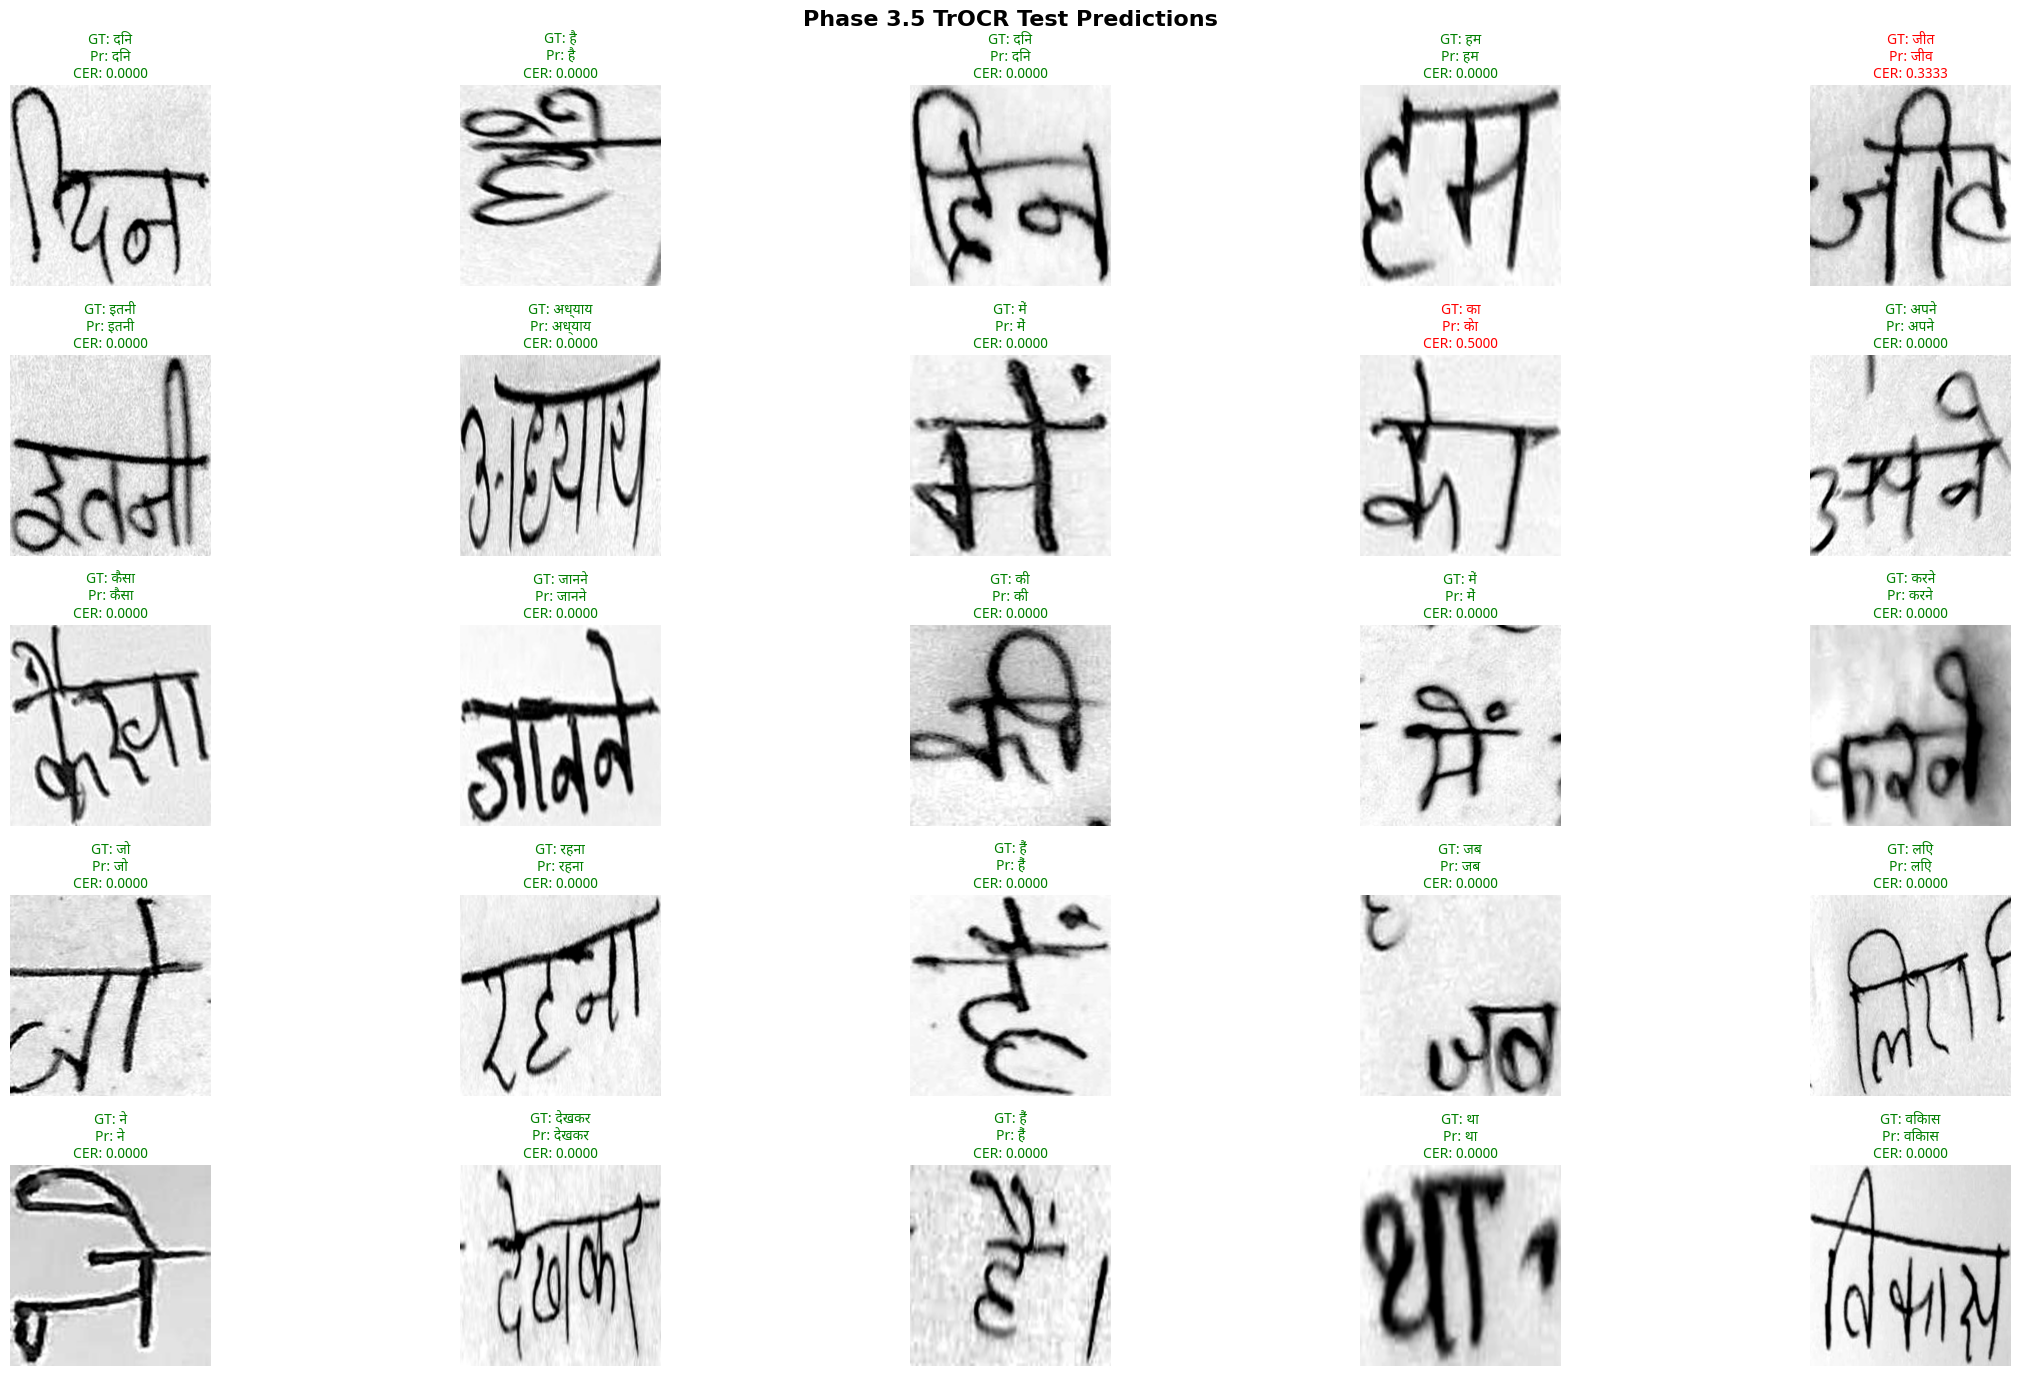

In [19]:
model.eval()
sample_loader = DataLoader(test_dataset, batch_size=25, shuffle=True, collate_fn=collate_fn)
batch = next(iter(sample_loader))

with torch.no_grad():
    generated = model.generate(
        batch["pixel_values"].to(device),
        max_length=MAX_TARGET_LEN,
        num_beams=NUM_BEAMS_TEST,
        decoder_start_token_id=BOS_ID,
    )

fig, axes = plt.subplots(5, 5, figsize=(24, 14))
fig.suptitle("Phase 3.5 TrOCR Test Predictions", fontweight="bold", fontsize=16)

for i, ax in enumerate(axes.flat):
    if i >= batch["pixel_values"].shape[0]:
        ax.axis("off")
        continue
    
    # Prepare image for display
    img = batch["pixel_values"][i].permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    
    # Decode prediction and ground truth
    pred_text = decode_tokens(generated[i])
    gt_ids = batch["labels"][i]
    gt_ids = gt_ids[gt_ids != -100].tolist()
    gt_text = decode_tokens(gt_ids)
    
    # Calculate CER
    cer = editdistance.eval(pred_text, gt_text) / max(len(gt_text), 1) if gt_text else float(len(pred_text) > 0)
    
    # Colour: green if exact match, else red
    color = "green" if pred_text == gt_text else "red"
    
    ax.imshow(img)
    ax.set_title(f"GT: {gt_text}\nPr: {pred_text}\nCER: {cer:.4f}", 
                 fontsize=8, fontproperties=DEVA_FONT, color=color)
    ax.axis("off")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "test_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

## 16. Error Analysis


TOP 15 WORST PREDICTIONS (Validation subset)
#    CER      GT Length  Ground Truth                   Prediction                    
--------------------------------------------------------------------------------
1    1.0000   2          23                             २                             
2    1.0000   2          २४                             20                            
3    0.6667   6          अन्ततः                         अलत                           
4    0.6667   3          शेष                            रोष                           
5    0.6667   3          अंत                            अब                            
6    0.6000   5          ट्रेन                          देन                           
7    0.5000   2          है                             है।                           
8    0.5000   2          थे                             ये                            
9    0.5000   2          थे                             थे।                           
10 

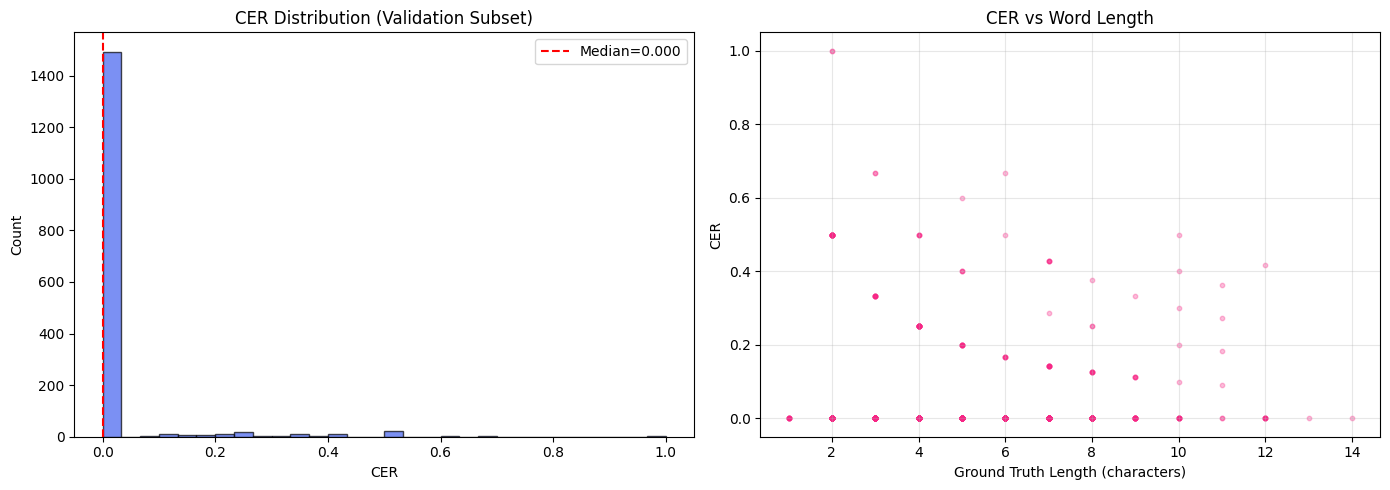


Char          Total   Errors   Error%
------------------------------------
ँ                 7        2    28.6%
थ                28        6    21.4%
घ                 5        1    20.0%
ृ                 5        1    20.0%
.                 6        1    16.7%
ण                22        3    13.6%
ू                30        3    10.0%
ई                22        2     9.1%
्               274       22     8.0%
ठ                13        1     7.7%
श                72        5     6.9%
ध                29        2     6.9%
ौ                16        1     6.2%
ु                97        6     6.2%
ं               195       11     5.6%

Exact match on subset: 1493/1600 (93.3%)


In [20]:
# Cell 16: Error Analysis (Phase 3.5 – matches Phase 3 visuals)
# 1. Top-15 worst predictions (text table)
# 2. CER distribution histogram
# 3. CER vs word length scatterplot
# 4. Per-character error rate table (original)

model.eval()

# ---------- Evaluate on a validation subset (first 50 batches ≈ 1600 samples) ----------
errors_list = []          # for worst predictions and plots
char_errors = Counter()
char_totals = Counter()

sample_val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False,
                               collate_fn=collate_fn)

with torch.no_grad():
    for bi, batch in enumerate(sample_val_loader):
        if bi >= 50: break   # same limit as before
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"]

        # Greedy decoding for speed (you can use beam if you prefer)
        generated = model.generate(pixel_values, max_length=MAX_TARGET_LEN,
                                   num_beams=1, decoder_start_token_id=BOS_ID)

        for i in range(pixel_values.size(0)):
            pred = decode_tokens(generated[i])
            gt_ids = labels[i][labels[i] != -100].tolist()
            gt = decode_tokens(gt_ids)

            # CER
            cer = editdistance.eval(pred, gt) / max(len(gt), 1) if gt else float(len(pred) > 0)

            errors_list.append({
                'gt': gt,
                'pred': pred,
                'cer': cer,
                'gt_len': len(gt)
            })

            # Per‑character errors (for final table)
            for ch in gt:
                char_totals[ch] += 1
            if pred != gt:
                for j, ch in enumerate(gt):
                    if j >= len(pred) or pred[j] != ch:
                        char_errors[ch] += 1

# ---------- Convert to DataFrame and sort ----------
errors_df = pd.DataFrame(errors_list).sort_values('cer', ascending=False)

# --- 1. Print Top-15 worst predictions ---
print("\n" + "="*80)
print("TOP 15 WORST PREDICTIONS (Validation subset)")
print("="*80)
print(f"{'#':<4} {'CER':<8} {'GT Length':<10} {'Ground Truth':<30} {'Prediction':<30}")
print("-"*80)
for rank, (_, row) in enumerate(errors_df.head(15).iterrows(), 1):
    print(f"{rank:<4} {row['cer']:.4f}   {row['gt_len']:<10} {row['gt']:<30} {row['pred']:<30}")

# --- 2 & 3. Plots: CER distribution and CER vs word length ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 2: CER distribution histogram
axes[0].hist(errors_df['cer'], bins=30, color='#4361ee', edgecolor='black', alpha=0.7)
axes[0].set_title('CER Distribution (Validation Subset)')
axes[0].set_xlabel('CER')
axes[0].set_ylabel('Count')
axes[0].axvline(errors_df['cer'].median(), color='red', ls='--',
                label=f'Median={errors_df["cer"].median():.3f}')
axes[0].legend()

# Plot 3: CER vs. word length
axes[1].scatter(errors_df['gt_len'], errors_df['cer'],
                alpha=0.3, s=10, color='#f72585')
axes[1].set_title('CER vs Word Length')
axes[1].set_xlabel('Ground Truth Length (characters)')
axes[1].set_ylabel('CER')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 4. Per‑character error table (original) ---
print(f"\n{'Char':<10} {'Total':>8} {'Errors':>8} {'Error%':>8}")
print("-" * 36)
for ch in sorted(char_totals.keys(),
                 key=lambda c: char_errors.get(c, 0) / max(char_totals[c], 1),
                 reverse=True)[:20]:
    t = char_totals[ch]
    e = char_errors.get(ch, 0)
    if t >= 5:
        print(f"{ch:<10} {t:>8} {e:>8} {e/t*100:>7.1f}%")

# Overall exact‑match
exact = sum(1 for _, r in errors_df.iterrows() if r['gt'] == r['pred'])
print(f"\nExact match on subset: {exact}/{len(errors_df)} ({exact/len(errors_df)*100:.1f}%)")

## 17. Save Final Artifacts

In [21]:
# Save training history
with open(RESULTS_DIR / "training_history.json", "w") as f:
    json.dump(history, f, indent=2)

# Save results summary
results = {
    "model": MODEL_NAME,
    "vocab_size": VOCAB_SIZE,
    "best_epoch": ckpt["epoch"],
    "best_val_cer": ckpt["val_cer"],
    "best_val_wer": ckpt["val_wer"],
    "test_cer_greedy": greedy_cer,
    "test_wer_greedy": greedy_wer,
    "test_cer_beam": beam_cer,
    "test_wer_beam": beam_wer,
    "char_accuracy_beam": (1 - beam_cer) * 100,
    "word_accuracy_beam": (1 - beam_wer) * 100,
    "total_params": sum(p.numel() for p in model.parameters()),
    "epochs_phase_a": EPOCHS_PHASE_A,
    "epochs_phase_b": EPOCHS_PHASE_B,
    "batch_size": BATCH_SIZE,
    "dataset_train": len(train_df),
    "dataset_val": len(val_df),
    "dataset_test": len(test_df),
}
with open(RESULTS_DIR / "phase3_5_results.json", "w") as f:
    json.dump(results, f, indent=2)

# Copy model
import shutil
shutil.copy(CKPT_DIR / "best_model.pt", OUTPUT_DIR / "best_model_trocr.pt")

print("="*60)
print("PHASE 3.5 COMPLETE")
print("="*60)
print(f"Architecture    : TrOCR-Small (ViT + GPT-2)")
print(f"Parameters      : {sum(p.numel() for p in model.parameters()):,}")
print(f"Best val CER    : {ckpt['val_cer']:.4f}")
print(f"Test CER (grdy) : {greedy_cer:.4f}")
print(f"Test WER (grdy) : {greedy_wer:.4f}")
print(f"Test CER (beam) : {beam_cer:.4f}")
print(f"Test WER (beam) : {beam_wer:.4f}")
print(f"Char acc (beam) : {(1-beam_cer)*100:.2f}%")
print(f"Word acc (beam) : {(1-beam_wer)*100:.2f}%")
print(f"\nCheckpoint : {CKPT_DIR / 'best_model.pt'}")
print(f"Results    : {RESULTS_DIR}")


PHASE 3.5 COMPLETE
Architecture    : TrOCR-Small (ViT + GPT-2)
Parameters      : 28,877,824
Best val CER    : 0.0210
Test CER (grdy) : 0.0516
Test WER (grdy) : 0.1294
Test CER (beam) : 0.0522
Test WER (beam) : 0.1314
Char acc (beam) : 94.78%
Word acc (beam) : 86.86%

Checkpoint : /kaggle/working/phase3_5/checkpoints/best_model.pt
Results    : /kaggle/working/phase3_5/results


In [23]:
# Force download best_model.pt from Kaggle notebook
from IPython.display import FileLink
import shutil, os

# Copy checkpoint to /kaggle/working/ (which is accessible for download)
src = '/kaggle/working/checkpoints/best_model_trocr.pt'
dst = '/kaggle/working/best_model.pt'

if os.path.exists(src):
    shutil.copy2(src, dst)
    print(f"Model copied to {dst}")
    print(f"Size: {os.path.getsize(dst) / 1e6:.1f} MB")
    display(FileLink('best_model.pt', result_html_prefix="Click to download: "))
else:
    print(f"ERROR: {src} not found. Train the model first.")

ERROR: /kaggle/working/checkpoints/best_model_trocr.pt not found. Train the model first.
